In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42
PROC = "../data/processed"

NUM = ["accommodates", "bedrooms", "beds", "bathrooms",
       "number_of_reviews", "number_of_reviews_ltm", "reviews_per_month",
       "availability_365", "minimum_nights", "review_scores_rating",
       "latitude", "longitude"]
CAT = ["room_type", "property_type", "neighbourhood_cleansed"]
SKEWED = ["number_of_reviews", "number_of_reviews_ltm", "reviews_per_month", "minimum_nights"]


def _log1p_nonneg(x):
    return np.log1p(np.clip(x, 0, None))


def _clip5(x):
    return np.clip(x, -5, 5)


def build_nn_preprocessor(num_cols=None, cat_cols=None):
    """Safe for gradient-based training: skewed counts are log-transformed and
    every scaled feature is clipped to [-5, 5]."""
    num_cols = NUM if num_cols is None else num_cols
    cat_cols = CAT if cat_cols is None else cat_cols
    skewed_cols = [c for c in num_cols if c in SKEWED]
    normal_cols = [c for c in num_cols if c not in SKEWED]
    skewed = Pipeline([
        ("imp", SimpleImputer(strategy="median", add_indicator=True)),
        ("log", FunctionTransformer(_log1p_nonneg)),
        ("sc", StandardScaler()),
        ("clip", FunctionTransformer(_clip5)),
    ])
    normal = Pipeline([
        ("imp", SimpleImputer(strategy="median", add_indicator=True)),
        ("sc", StandardScaler()),
        ("clip", FunctionTransformer(_clip5)),
    ])
    cat = Pipeline([
        ("imp", SimpleImputer(strategy="constant", fill_value="missing")),
        ("oh", OneHotEncoder(handle_unknown="ignore", min_frequency=20)),
    ])
    parts = [("skew", skewed, skewed_cols), ("norm", normal, normal_cols)]
    if cat_cols:
        parts.append(("cat", cat, cat_cols))
    return ColumnTransformer(parts)


def make_mlp(num_cols=None, cat_cols=None):
    # Paper settings: 2 hidden layers (64, 32), SGD + Nesterov momentum 0.9,
    # lr 0.005, L2 = 0.005, early stopping on 10% of the training data, patience 10.
    return Pipeline([
        ("prep", build_nn_preprocessor(num_cols, cat_cols)),
        ("model", MLPRegressor(
            hidden_layer_sizes=(64, 32), activation="relu",
            solver="sgd", nesterovs_momentum=True, momentum=0.9,
            learning_rate_init=0.005, alpha=0.005, batch_size=64,
            early_stopping=True, validation_fraction=0.1,
            n_iter_no_change=10, tol=1e-4, max_iter=300,
            random_state=SEED)),
    ])


def evaluate(pipe, df, num_cols=None, cat_cols=None):
    num_cols = NUM if num_cols is None else num_cols
    cat_cols = CAT if cat_cols is None else cat_cols
    pred_log = pipe.predict(df[num_cols + cat_cols])
    pred_usd = np.expm1(pred_log)
    return {"R2_log": r2_score(df["log_price"], pred_log),
            "RMSE_log": np.sqrt(mean_squared_error(df["log_price"], pred_log)),
            "MAE_usd": mean_absolute_error(df["price"], pred_usd),
            "RMSE_usd": np.sqrt(mean_squared_error(df["price"], pred_usd))}


def load_city(city):
    return [pd.read_pickle(f"{PROC}/{city}_{s}.pkl") for s in ("train", "val", "test")]

In [7]:
nn_rows, nn_models = [], {}
for city in ["nyc", "paris", "berlin"]:
    train, val, test = load_city(city)
    pipe = make_mlp()
    pipe.fit(train[NUM + CAT], train["log_price"])
    nn_models[city] = pipe
    for split_name, part in [("train", train), ("val", val), ("test", test)]:
        nn_rows.append({"city": city, "model": "MLP", "split": split_name, **evaluate(pipe, part)})
    print(city, "stopped after", pipe.named_steps["model"].n_iter_, "epochs")

nn_results = pd.DataFrame(nn_rows)
display(nn_results.round(4))

nyc stopped after 68 epochs
paris stopped after 42 epochs
berlin stopped after 43 epochs


,city,model,split,R2_log,RMSE_log,MAE_usd,RMSE_usd
0,nyc,MLP,train,0.7769,0.3080,42.3636,62.3650
1,nyc,MLP,val,0.7362,0.3341,45.7402,66.7893
2,nyc,MLP,test,0.7179,0.3392,47.0012,68.7707
3,paris,MLP,train,0.7571,0.3062,46.1636,64.5840
4,paris,MLP,val,0.7211,0.3276,48.6514,69.0657
5,paris,MLP,test,0.7500,0.3124,47.6126,66.9292
6,berlin,MLP,train,0.8784,0.3180,33.4225,52.2261
7,berlin,MLP,val,0.8723,0.3282,33.2201,48.7411
8,berlin,MLP,test,0.8547,0.3315,35.5390,53.7671


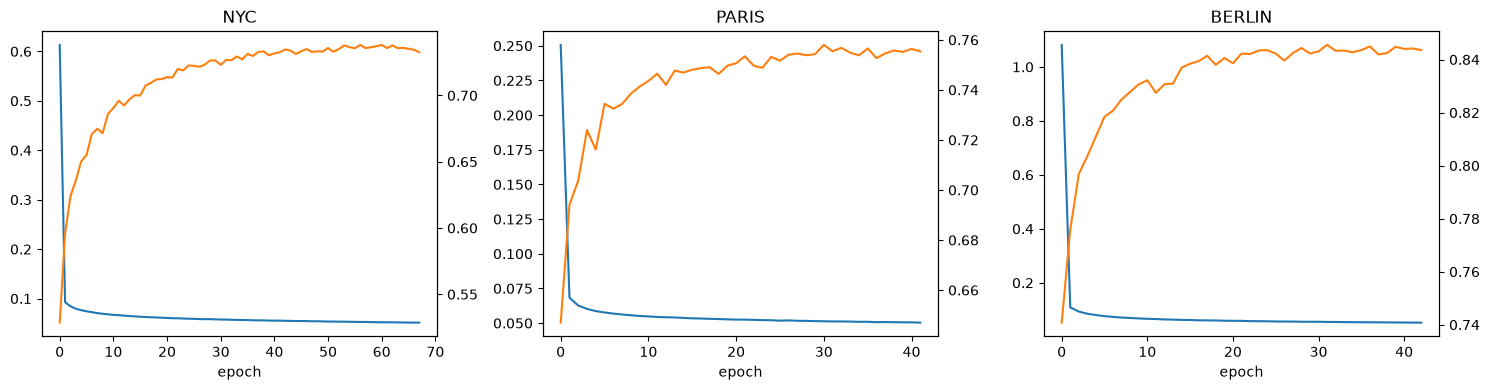

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, city in zip(axes, nn_models):
    m = nn_models[city].named_steps["model"]
    ax.plot(m.loss_curve_, label="train loss")
    ax2 = ax.twinx()
    ax2.plot(m.validation_scores_, color="tab:orange", label="val R2")
    ax.set_title(city.upper())
    ax.set_xlabel("epoch")
plt.tight_layout()
plt.show()

In [9]:
data = {c: dict(zip(["train", "val", "test"], load_city(c))) for c in ["nyc", "paris", "berlin"]}
berlin_all = pd.concat(data["berlin"].values(), ignore_index=True)  # never used for training here

GENERIC_NUM = [c for c in NUM if c not in ("latitude", "longitude")]
GENERIC_CAT = [c for c in CAT if c != "neighbourhood_cleansed"]

FEATURE_SETS = {
    "all features": (NUM, CAT),
    "generic only (no location)": (GENERIC_NUM, GENERIC_CAT),
}
TRAIN_SETS = {"NYC only": ["nyc"], "Paris only": ["paris"], "NYC + Paris": ["nyc", "paris"]}
EVAL_SETS = {"NYC test": data["nyc"]["test"],
             "Paris test": data["paris"]["test"],
             "Berlin (unseen city)": berlin_all}

In [10]:
rows = []
for fs_name, (num_cols, cat_cols) in FEATURE_SETS.items():
    for ts_name, cities in TRAIN_SETS.items():
        train = pd.concat([data[c]["train"] for c in cities], ignore_index=True)
        pipe = make_mlp(num_cols, cat_cols)
        pipe.fit(train[num_cols + cat_cols], train["log_price"])
        for ev_name, df in EVAL_SETS.items():
            rows.append({"features": fs_name, "trained_on": ts_name, "evaluated_on": ev_name,
                         **evaluate(pipe, df, num_cols, cat_cols)})
        print("done:", fs_name, "|", ts_name)

transfer = pd.DataFrame(rows)
for fs_name in FEATURE_SETS:
    print("\n" + fs_name)
    print(transfer[transfer.features == fs_name]
          .pivot(index="trained_on", columns="evaluated_on", values="R2_log").round(3))

done: all features | NYC only
done: all features | Paris only
done: all features | NYC + Paris
done: generic only (no location) | NYC only
done: generic only (no location) | Paris only
done: generic only (no location) | NYC + Paris

all features
evaluated_on  Berlin (unseen city)  NYC test  Paris test
trained_on                                              
NYC + Paris                  0.719     0.725       0.741
NYC only                     0.518     0.718       0.433
Paris only                  -1.761    -4.515       0.750

generic only (no location)
evaluated_on  Berlin (unseen city)  NYC test  Paris test
trained_on                                              
NYC + Paris                  0.631     0.528       0.616
NYC only                     0.133     0.646       0.045
Paris only                   0.733    -0.115       0.671


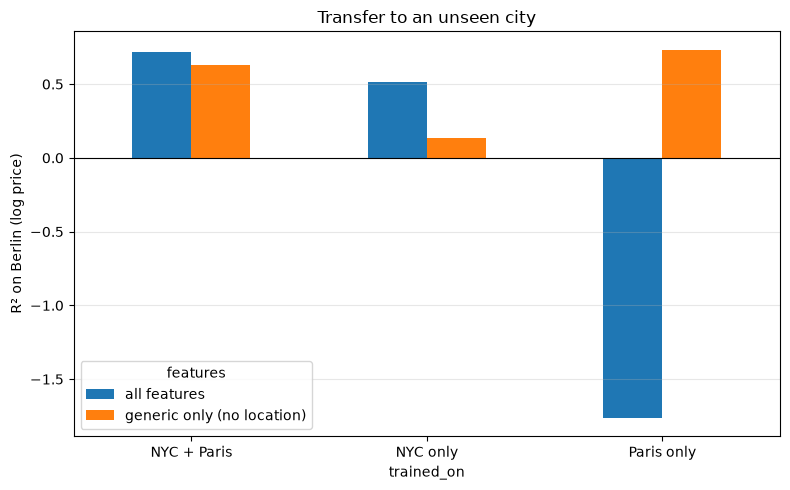

In [11]:
berlin_r2 = (transfer[transfer.evaluated_on == "Berlin (unseen city)"]
             .pivot(index="trained_on", columns="features", values="R2_log"))
berlin_r2.plot(kind="bar", figsize=(8, 5))
plt.ylabel("R² on Berlin (log price)")
plt.title("Transfer to an unseen city")
plt.xticks(rotation=0)
plt.axhline(0, color="black", linewidth=0.8)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()